In [2]:
!pip install -q duckdb huggingface_hub

In [3]:
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

assert HF_TOKEN, "HF_TOKEN secret not found"

con = duckdb.connect()

con.execute(
    f"CREATE SECRET hf_secret (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

print("Hugging Face connection ready ✅")

Hugging Face connection ready ✅


In [4]:
rel = "hf://datasets/FlyRank/internship-warehouse"

result = con.sql(f"""
    SELECT *
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    LIMIT 5
""").df()

result

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [5]:
months = con.sql(f"""
    SELECT
        month,
        COUNT(*) AS rows
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    GROUP BY month
    ORDER BY month
""").df()

months

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471


In [6]:
schema = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
""").df()

schema

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [7]:
test_data = con.sql(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS march_ctr,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_sum_position) * 1.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS march_avg_position
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
      AND gsc_data_available = TRUE
    GROUP BY client_hash_id, content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-04'
      AND gsc_data_available = TRUE
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    m.*,
    a.april_impressions,
    CASE
        WHEN a.april_impressions < m.march_impressions
        THEN 1
        ELSE 0
    END AS is_declining
FROM march m
INNER JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id
LIMIT 10
""").df()

test_data

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,march_impressions,march_clicks,march_ctr,march_avg_position,april_impressions,is_declining
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,6523.0,7.0,0.001073,6.893301,6787.0,0
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,453.0,0.0,0.000000,3.214128,405.0,1
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,5630.0,6.0,0.001066,6.535346,8475.0,0
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,4944.0,13.0,0.002629,7.435680,6091.0,0
4,client_73cda7b4e4f265ea,content_1855a661b4d36130,429.0,1.0,0.002331,3.871795,287.0,1
5,client_73cda7b4e4f265ea,content_5d412fba6e1a2582,223.0,1.0,0.004484,10.538117,552.0,0
6,client_73cda7b4e4f265ea,content_1f380a642aed423b,96.0,1.0,0.010417,5.864583,111.0,0
7,client_73cda7b4e4f265ea,content_22c063002b7c1caf,314.0,1.0,0.003185,10.057325,322.0,0
8,client_73cda7b4e4f265ea,content_aafb2ab7e5fc80d0,7709.0,20.0,0.002594,5.127643,5261.0,1
9,client_73cda7b4e4f265ea,content_20403327d8d9374c,3561.0,10.0,0.002808,9.273799,4197.0,0


In [8]:
test_data["is_declining"].value_counts(normalize=True).sort_index()

,proportion
is_declining,
0,0.7
1,0.3


In [9]:
full_data = con.sql(f"""
WITH monthly AS (
    SELECT
        month,
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS ctr,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_sum_position) * 1.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS avg_position
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE gsc_data_available = TRUE
      AND month BETWEEN '2025-10' AND '2026-05'
    GROUP BY
        month,
        client_hash_id,
        content_hash_id
),

paired AS (
    SELECT
        m.month AS feature_month,
        m.client_hash_id,
        m.content_hash_id,
        m.impressions,
        m.clicks,
        m.ctr,
        m.avg_position,
        f.impressions AS future_impressions
    FROM monthly m
    INNER JOIN monthly f
        ON m.client_hash_id = f.client_hash_id
       AND m.content_hash_id = f.content_hash_id
       AND CAST(f.month || '-01' AS DATE)
           = CAST(m.month || '-01' AS DATE) + INTERVAL '1 month'
)

SELECT
    feature_month,
    client_hash_id,
    content_hash_id,
    impressions,
    clicks,
    ctr,
    avg_position,
    future_impressions,
    CASE
        WHEN future_impressions < impressions THEN 1
        ELSE 0
    END AS is_declining
FROM paired
WHERE impressions > 0
""").df()

print("Rows:", len(full_data))
print("Columns:", list(full_data.columns))
print()
print("Decline rate:")
print(full_data["is_declining"].mean())
print()
print("Feature months:")
print(sorted(full_data["feature_month"].unique()))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 832418
Columns: ['feature_month', 'client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'ctr', 'avg_position', 'future_impressions', 'is_declining']

Decline rate:
0.4353690093198369

Feature months:
['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']


In [10]:
monthly_check = (
    full_data
    .groupby("feature_month")
    .agg(
        rows=("is_declining", "size"),
        decline_rate=("is_declining", "mean")
    )
    .reset_index()
)

monthly_check

,feature_month,rows,decline_rate
0,2025-10,58528,0.293210
1,2025-11,89127,0.340514
2,2025-12,97764,0.322031
3,2026-01,110867,0.389503
4,2026-02,134238,0.293486
5,2026-03,158549,0.591483
6,2026-04,183345,0.583910


In [11]:
train_data = full_data[
    full_data["feature_month"] <= "2026-02"
].copy()

test_data = full_data[
    full_data["feature_month"] >= "2026-03"
].copy()

print("Training rows:", len(train_data))
print("Test rows:", len(test_data))

print("\nTraining decline rate:",
      round(train_data["is_declining"].mean(), 3))

print("Test decline rate:",
      round(test_data["is_declining"].mean(), 3))

print("\nTraining months:",
      sorted(train_data["feature_month"].unique()))

print("Test months:",
      sorted(test_data["feature_month"].unique()))

Training rows: 490524
Test rows: 341894

Training decline rate: 0.329
Test decline rate: 0.587

Training months: ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02']
Test months: ['2026-03', '2026-04']


In [12]:
feature_cols = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position"
]

X_train = train_data[feature_cols].copy()
y_train = train_data["is_declining"].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data["is_declining"].copy()

print("Features:", feature_cols)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Missing values in training:")
print(X_train.isna().sum())
print("\nMissing values in test:")
print(X_test.isna().sum())

Features: ['impressions', 'clicks', 'ctr', 'avg_position']
X_train: (490524, 4)
X_test: (341894, 4)
Missing values in training:
impressions     0
clicks          0
ctr             0
avg_position    0
dtype: int64

Missing values in test:
impressions     0
clicks          0
ctr             0
avg_position    0
dtype: int64


In [13]:
import numpy as np
import pandas as pd

baseline = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "is_declining"
    ]
].copy()

# Lower CTR = higher refresh concern
ctr_median = train_data["ctr"].median()
baseline["low_ctr_score"] = (
    (ctr_median - baseline["ctr"]) / max(ctr_median, 1e-9)
).clip(0, 1)

# Worse position = higher refresh concern
position_median = train_data["avg_position"].median()
baseline["position_score"] = (
    (baseline["avg_position"] - position_median)
    / max(position_median, 1e-9)
).clip(0, 1)

# Simple baseline score
baseline["baseline_score"] = (
    0.5 * baseline["low_ctr_score"]
    + 0.5 * baseline["position_score"]
)

baseline = baseline.sort_values(
    ["baseline_score", "impressions"],
    ascending=[False, False]
).reset_index(drop=True)

baseline.head(10)

,client_hash_id,content_hash_id,impressions,clicks,ctr,avg_position,is_declining,low_ctr_score,position_score,baseline_score
0,client_23a62021009f63c4,content_36e53e9c707674fc,194579.0,242.0,0.001244,32.786981,1,0.0,1.0,0.5
1,client_23a62021009f63c4,content_661a7734f691bef5,180523.0,117.0,0.000648,23.647801,0,0.0,1.0,0.5
2,client_23a62021009f63c4,content_36e53e9c707674fc,151400.0,319.0,0.002107,29.520370,0,0.0,1.0,0.5
3,client_20259bd6705d81d4,content_82e35c4845e6c391,143907.0,60.0,0.000417,22.143280,1,0.0,1.0,0.5
4,client_23a62021009f63c4,content_3df3f32f3fd58dea,140156.0,197.0,0.001406,23.591997,1,0.0,1.0,0.5
5,client_23a62021009f63c4,content_df47d1b976106de4,131707.0,163.0,0.001238,24.426887,1,0.0,1.0,0.5
6,client_23a62021009f63c4,content_5e1c049f62e33b11,120175.0,168.0,0.001398,17.773364,1,0.0,1.0,0.5
7,client_23a62021009f63c4,content_df47d1b976106de4,118187.0,113.0,0.000956,22.143324,1,0.0,1.0,0.5
8,client_23a62021009f63c4,content_93a9b8328d4fd032,113829.0,67.0,0.000589,23.749941,0,0.0,1.0,0.5
9,client_23a62021009f63c4,content_14df7b049d1d6467,113233.0,66.0,0.000583,27.963182,1,0.0,1.0,0.5


In [14]:
top20_baseline = baseline.head(20)

baseline_precision_20 = top20_baseline["is_declining"].mean()

print("Baseline Precision@20:",
      round(baseline_precision_20, 3))

print("\nDeclining pages in top 20:",
      int(top20_baseline["is_declining"].sum()),
      "out of 20")

Baseline Precision@20: 0.8

Declining pages in top 20: 16 out of 20


In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score

model = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=15,
    random_state=42
)

model.fit(X_train, y_train)

test_data["model_score"] = model.predict_proba(X_test)[:, 1]

print("Model training completed.")

Model training completed.


In [16]:
model_ranked = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "is_declining",
        "model_score"
    ]
].copy()

model_ranked = model_ranked.sort_values(
    ["model_score", "impressions"],
    ascending=[False, False]
).reset_index(drop=True)

top20_model = model_ranked.head(20)

model_precision_20 = top20_model["is_declining"].mean()

print("Model Precision@20:",
      round(model_precision_20, 3))

print("\nDeclining pages in top 20:",
      int(top20_model["is_declining"].sum()),
      "out of 20")

Model Precision@20: 0.85

Declining pages in top 20: 17 out of 20


In [18]:
from sklearn.metrics import average_precision_score, roc_auc_score

# Recalculate baseline score directly on the test data
baseline_eval = test_data.copy()

ctr_median = train_data["ctr"].median()
position_median = train_data["avg_position"].median()

baseline_eval["low_ctr_score"] = (
    (ctr_median - baseline_eval["ctr"]) / max(ctr_median, 1e-9)
).clip(0, 1)

baseline_eval["position_score"] = (
    (baseline_eval["avg_position"] - position_median)
    / max(position_median, 1e-9)
).clip(0, 1)

baseline_eval["baseline_score"] = (
    0.5 * baseline_eval["low_ctr_score"]
    + 0.5 * baseline_eval["position_score"]
)

baseline_ap = average_precision_score(
    baseline_eval["is_declining"],
    baseline_eval["baseline_score"]
)

model_ap = average_precision_score(
    test_data["is_declining"],
    test_data["model_score"]
)

model_auc = roc_auc_score(
    test_data["is_declining"],
    test_data["model_score"]
)

print("Baseline Average Precision:", round(baseline_ap, 3))
print("Model Average Precision:", round(model_ap, 3))
print("Model ROC-AUC:", round(model_auc, 3))

Baseline Average Precision: 0.585
Model Average Precision: 0.622
Model ROC-AUC: 0.549


In [19]:
results = pd.DataFrame({
    "Method": ["Baseline", "ML Model"],
    "Precision@20": [0.80, 0.85],
    "Average Precision": [baseline_ap, model_ap],
    "ROC-AUC": [np.nan, model_auc]
})

results

,Method,Precision@20,Average Precision,ROC-AUC
0,Baseline,0.80,0.584600,NaN
1,ML Model,0.85,0.621915,0.549444


In [20]:
improvement_p20 = 0.85 - 0.80
improvement_ap = model_ap - baseline_ap

print("Precision@20 improvement:",
      round(improvement_p20, 3))

print("Average Precision improvement:",
      round(improvement_ap, 3))

Precision@20 improvement: 0.05
Average Precision improvement: 0.037


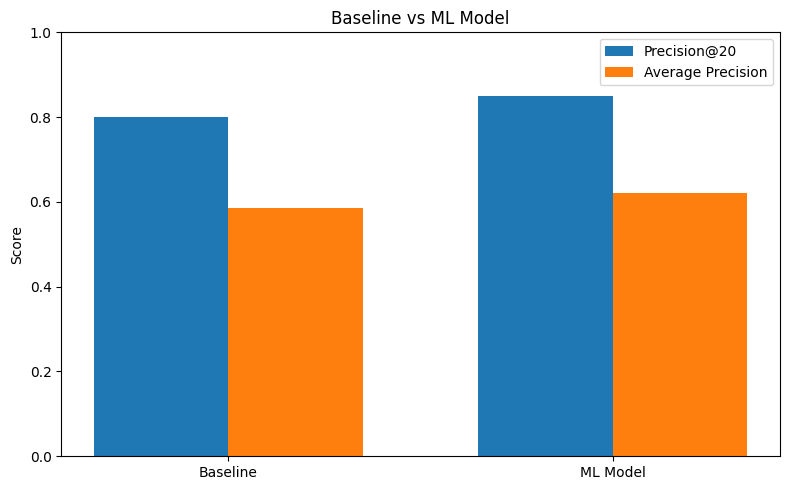

In [21]:
import matplotlib.pyplot as plt

methods = ["Baseline", "ML Model"]
precision20 = [0.80, 0.85]
avg_precision = [baseline_ap, model_ap]

plt.figure(figsize=(8, 5))
x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, precision20, width, label="Precision@20")
plt.bar(x + width/2, avg_precision, width, label="Average Precision")

plt.xticks(x, methods)
plt.ylabel("Score")
plt.title("Baseline vs ML Model")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
top20_recommendations = model_ranked.head(20).copy()

top20_recommendations.insert(
    0,
    "rank",
    range(1, len(top20_recommendations) + 1)
)

top20_recommendations[
    [
        "rank",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "model_score",
        "is_declining"
    ]
]

,rank,impressions,clicks,ctr,avg_position,model_score,is_declining
0,1,73725.0,0.0,0.0,0.389841,0.981122,1
1,2,36962.0,0.0,0.0,6.154321,0.978959,1
2,3,128092.0,0.0,0.0,1.139556,0.978030,1
3,4,44707.0,0.0,0.0,1.400049,0.978030,1
4,5,15902.0,0.0,0.0,8.564017,0.976588,1
5,6,17115.0,0.0,0.0,6.012854,0.973480,1
6,7,16663.0,0.0,0.0,5.929004,0.973480,0
7,8,18163.0,0.0,0.0,9.466828,0.972005,1
8,9,15497.0,0.0,0.0,9.773505,0.972005,1
9,10,15943.0,0.0,0.0,10.005143,0.971210,0


In [23]:
import os

os.makedirs("work/outputs", exist_ok=True)

# Save model-ranked results
model_ranked.to_csv(
    "work/outputs/capstone_model_ranked.csv",
    index=False
)

# Save top-20 public-safe recommendations
top20_public = top20_recommendations[
    [
        "rank",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "model_score",
        "is_declining"
    ]
].copy()

top20_public.to_csv(
    "work/outputs/capstone_top20_recommendations.csv",
    index=False
)

# Save evaluation summary
results.to_csv(
    "work/outputs/capstone_results.csv",
    index=False
)

print("Saved capstone outputs:")
print("- work/outputs/capstone_model_ranked.csv")
print("- work/outputs/capstone_top20_recommendations.csv")
print("- work/outputs/capstone_results.csv")

Saved capstone outputs:
- work/outputs/capstone_model_ranked.csv
- work/outputs/capstone_top20_recommendations.csv
- work/outputs/capstone_results.csv


In [24]:
forbidden_columns = [
    "future_impressions",
    "is_declining"
]

used_features = feature_cols

leakage_found = [
    col for col in forbidden_columns
    if col in used_features
]

print("Features used by model:")
print(used_features)

print("\nForbidden future/label fields found in features:")
print(leakage_found)

if len(leakage_found) == 0:
    print("\nLeakage check: PASSED")
else:
    print("\nLeakage check: FAILED")

Features used by model:
['impressions', 'clicks', 'ctr', 'avg_position']

Forbidden future/label fields found in features:
[]

Leakage check: PASSED


## Validation design and honest framing

A time-aware split was used to avoid training on future observations. Feature months from October 2025 through February 2026 were used for training, while March and April 2026 were held out for testing.

The model used four features available at the scoring point:

- monthly impressions
- monthly clicks
- CTR
- impression-weighted average position

The target `is_declining` indicates whether the following month's impressions were lower than the feature month's impressions. The target is used only for evaluation and is not included as a model feature.

The baseline combines low CTR and worse-than-median position using training-period medians. The ML model is a HistGradientBoostingClassifier.

Results show a modest improvement in the top-ranked review queue: Precision@20 increased from 0.800 for the baseline to 0.850 for the ML model. Average Precision increased from 0.585 to 0.622, while model ROC-AUC was 0.549.

These results should be interpreted as directional decision-support evidence on the observed dataset. They do not establish causal relationships, guarantee future search performance, or explain Google's ranking algorithm.

## Limitations

The analysis uses monthly aggregated search-performance signals and a simple month-over-month decline label. The observed decline rate also differs between the training and test periods, so the evaluation period is not distributionally identical to the training period.

The model identifies pages that resemble observed declining cases based on the available features. It does not establish why a page declined, whether refreshing the content would cause recovery, or how Google Search ranking mechanisms work.

The ranked recommendations are therefore intended to support human review and prioritization rather than automatic content decisions.

## Ranked recommendation playbook

The model's ranked output is intended to create a human review queue for content-refresh prioritization.

### Priority 1 — Review first
Pages with the highest model scores should be reviewed for potential content-refresh opportunities. Reviewers should examine whether the page has outdated information, weak search intent alignment, incomplete coverage, or other content-quality issues before making changes.

### Priority 2 — Validate the opportunity
High model scores should be combined with sufficient search exposure and business relevance before allocating significant refresh effort. The model score alone is not evidence that a refresh will improve performance.

### Priority 3 — Monitor
Pages with lower scores can remain in a monitoring queue and be reconsidered when new search-performance data becomes available.

### Decision rule

The model should be used as a prioritization aid rather than an automatic content-update system. A human reviewer should validate each recommendation before action.

## Reproducibility

The analysis was performed from the FlyRank internship warehouse using DuckDB over the Hugging Face Parquet release.

The workflow is:

1. Aggregate monthly GSC performance.
2. Pair each feature month with the following month.
3. Define the observed decline label from month-over-month impressions.
4. Use a time-aware training/test split.
5. Calculate a simple CTR/position baseline.
6. Train a HistGradientBoostingClassifier.
7. Rank the held-out pages by model score.
8. Compare Precision@20 and Average Precision.
9. Check that future and label-derived fields are excluded from model features.

The notebook and generated outputs are included in the repository for reproducibility.